In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

In [ ]:
dataset= load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas() 

In [3]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [5]:
job_title = 'Data Analyst'

df_filtered = df[df['job_title_short'] == job_title].copy()
df_filtered['job_posted_month'] = df_filtered['job_posted_date'].dt.month

In [6]:
df_exploded = df_filtered.explode('job_skills')

In [7]:
df_pivot = df_exploded.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)

df_pivot.loc['total'] = df_pivot.sum()

df_pivot = df_pivot[df_pivot.loc['total'].sort_values(ascending=False).index]

df_pivot = df_pivot.drop('total')

In [9]:
df_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


<Axes: xlabel='job_posted_month'>

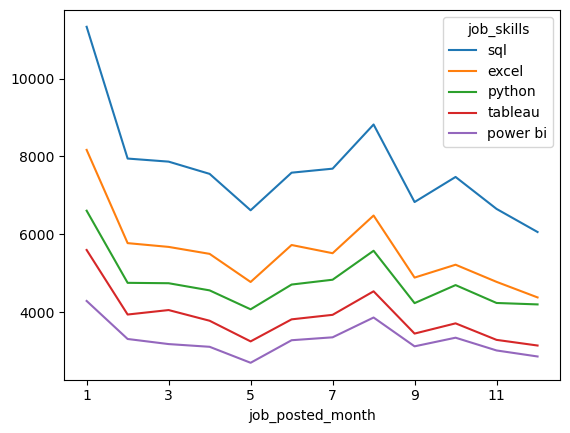

In [10]:
df_pivot.iloc[:, 0:5].plot(kind='line')

<Axes: xlabel='job_posted_month'>

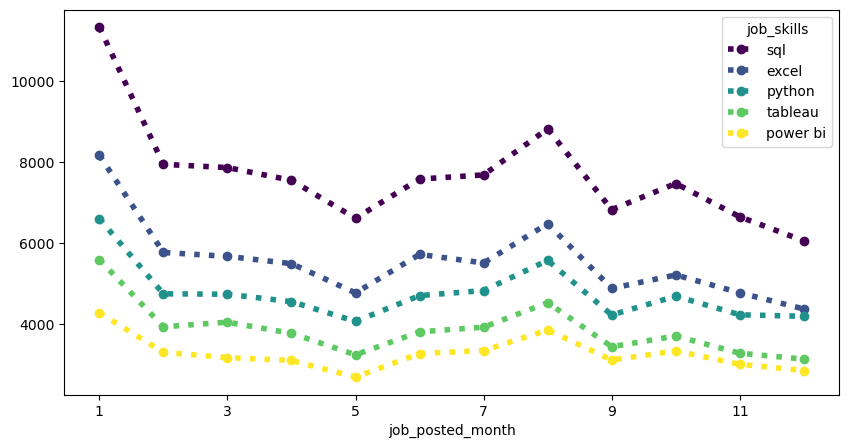

In [28]:
df_pivot.iloc[:, 0:5].plot(
    kind='line',
    linewidth=4,
    linestyle=':', #options '-','--','-.',':'
    colormap='viridis',
    marker='o',
    markersize=6,
    figsize=(10,5)#the figure dimensions
)

In [29]:
df = df[df['job_title_short'] == 'Data Analyst']
df = df.explode('job_skills')

In [35]:
skills_stats = df.groupby('job_skills').agg(
    skills_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')                                                
)

skills_stats = skills_stats.sort_values(by='skills_count', ascending=False).head(20)

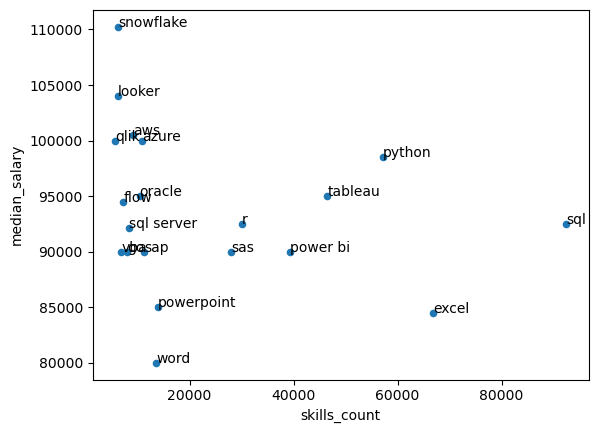

In [36]:
skills_stats.plot(kind='scatter', x='skills_count', y='median_salary')

for i, txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skills_count'].iloc[i],skills_stats['median_salary'].iloc[i],txt)

plt.show()

In [37]:
from adjustText import adjust_text

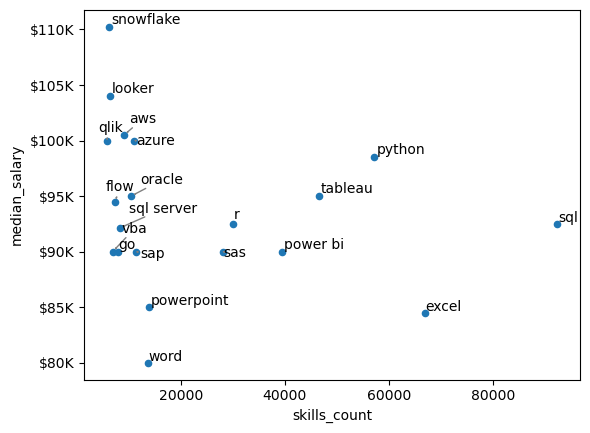

In [44]:
skills_stats.plot(kind='scatter', x='skills_count', y='median_salary')

texts = []

for i, txt in enumerate(skills_stats.index):
    texts.append(plt.text(skills_stats['skills_count'].iloc[i],skills_stats['median_salary'].iloc[i],txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.show()